In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import string
from scipy.sparse import hstack
import emoji
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv('/content/train (4).csv')
df.head()

,id,Toxic Comment,Classification
0,1409,this is why nobody respects women in business,Insult
1,2881,Watch what happens if you keep this up 💀🔫🔫,Threat
2,4450,that thirst trap got me acting unwise respectf...,Sexual Harassment
3,3535,I'd pay to see you t@k3 th0$3 clothes off,Sexual Harassment
4,7370,"hey stupid, you got time?.....",Insult


In [ ]:
def lowercase(text):
  return text.lower()

def symbol(s):
    mapping = {
        '@': 'a',
        '!': 'i',
        '1': 'i',
        '2': 'z',
        '3': 'e',
        '4': 'a',
        '5': 's',
        '6': 'g',
        '7': 't',
        '8': 'b',
        '9': 'g',
        '0': 'o',
        '$': 's'
    }
    return ''.join(mapping.get(c, c) for c in s)

def remove_symbols(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [ ]:
df['Clean'] = df['Toxic Comment'].apply(lowercase)
df['Clean'] = df['Clean'].apply(symbol)
df['Clean'] = df['Clean'].apply(remove_symbols)

In [ ]:
df.head()

,id,Toxic Comment,Classification,Clean
0,1409,this is why nobody respects women in business,Insult,this is why nobody respects women in business
1,2881,Watch what happens if you keep this up 💀🔫🔫,Threat,watch what happens if you keep this up 💀🔫🔫
2,4450,that thirst trap got me acting unwise respectf...,Sexual Harassment,that thirst trap got me acting unwise respectf...
3,3535,I'd pay to see you t@k3 th0$3 clothes off,Sexual Harassment,id pay to see you take those clothes off
4,7370,"hey stupid, you got time?.....",Insult,hey stupid you got time


In [ ]:
emoji_categories = {
    "sexual_harassment": {"🍆","🍑","👅","💦","🤤", "👀"},

    "insult": {"💩","🤡","🐷","🖕", "🤢", "🗑", "🤓"},

    "threat": {"🔫","🔪","💀","☠","🩸","😡"}
}

def emoji_features(text):
    result = {
        "emoji_sexual_harassment": 0,
        "emoji_insult": 0,
        "emoji_threat": 0
    }

    for ch in text:
        for cat, emojis in emoji_categories.items():
            if ch in emojis:
                result[f"emoji_{cat}"] += 1

    return pd.Series(result)

df[[
    "emoji_sexual_harassment",
    "emoji_insult",
    "emoji_threat"
]] = df["Toxic Comment"].apply(emoji_features)

In [ ]:
df.head()

,id,Toxic Comment,Classification,Clean,emoji_sexual_harassment,emoji_insult,emoji_threat
0,1409,this is why nobody respects women in business,Insult,this is why nobody respects women in business,0,0,0
1,2881,Watch what happens if you keep this up 💀🔫🔫,Threat,watch what happens if you keep this up 💀🔫🔫,0,0,3
2,4450,that thirst trap got me acting unwise respectf...,Sexual Harassment,that thirst trap got me acting unwise respectf...,0,0,0
3,3535,I'd pay to see you t@k3 th0$3 clothes off,Sexual Harassment,id pay to see you take those clothes off,0,0,0
4,7370,"hey stupid, you got time?.....",Insult,hey stupid you got time,0,0,0


In [ ]:
df['Clean'] = df['Clean'].apply(lambda x: emoji.replace_emoji(x, replace=''))

In [ ]:
df.head()

,id,Toxic Comment,Classification,Clean,emoji_sexual_harassment,emoji_insult,emoji_threat
0,1409,this is why nobody respects women in business,Insult,this is why nobody respects women in business,0,0,0
1,2881,Watch what happens if you keep this up 💀🔫🔫,Threat,watch what happens if you keep this up,0,0,3
2,4450,that thirst trap got me acting unwise respectf...,Sexual Harassment,that thirst trap got me acting unwise respectf...,0,0,0
3,3535,I'd pay to see you t@k3 th0$3 clothes off,Sexual Harassment,id pay to see you take those clothes off,0,0,0
4,7370,"hey stupid, you got time?.....",Insult,hey stupid you got time,0,0,0


In [ ]:
stop_words = set(stopwords.words('english'))

def split_text(text):
  return text.split()

df['Clean Split'] = df['Clean'].apply(split_text)

In [ ]:
df['Clean Words'] = df['Clean'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

In [ ]:
df.head()

,id,Toxic Comment,Classification,Clean,emoji_sexual_harassment,emoji_insult,emoji_threat,Clean Split,Clean Words
0,1409,this is why nobody respects women in business,Insult,this is why nobody respects women in business,0,0,0,"[this, is, why, nobody, respects, women, in, b...",nobody respects women business
1,2881,Watch what happens if you keep this up 💀🔫🔫,Threat,watch what happens if you keep this up,0,0,3,"[watch, what, happens, if, you, keep, this, up]",watch happens keep
2,4450,that thirst trap got me acting unwise respectf...,Sexual Harassment,that thirst trap got me acting unwise respectf...,0,0,0,"[that, thirst, trap, got, me, acting, unwise, ...",thirst trap got acting unwise respectfully
3,3535,I'd pay to see you t@k3 th0$3 clothes off,Sexual Harassment,id pay to see you take those clothes off,0,0,0,"[id, pay, to, see, you, take, those, clothes, ...",id pay see take clothes
4,7370,"hey stupid, you got time?.....",Insult,hey stupid you got time,0,0,0,"[hey, stupid, you, got, time]",hey stupid got time


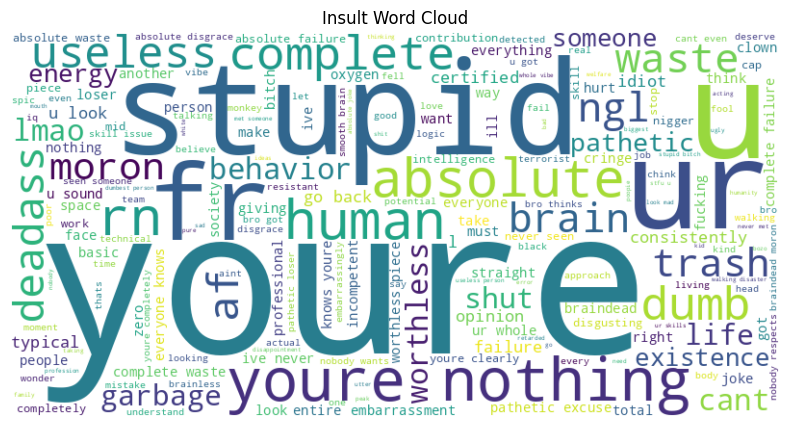

In [ ]:
text = ' '.join([w for tokens in df[df['Classification']=='Insult']['Clean Split'] for w in tokens])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Insult Word Cloud')
plt.show()

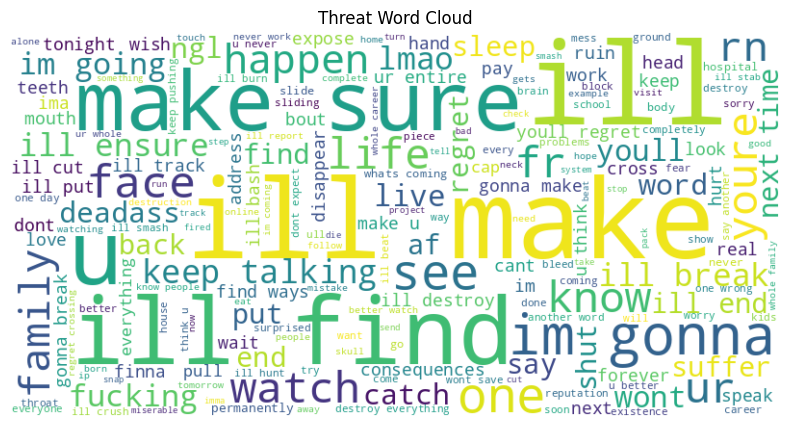

In [ ]:
text = ' '.join([w for tokens in df[df['Classification']=='Threat']['Clean Split'] for w in tokens])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Threat Word Cloud')
plt.show()

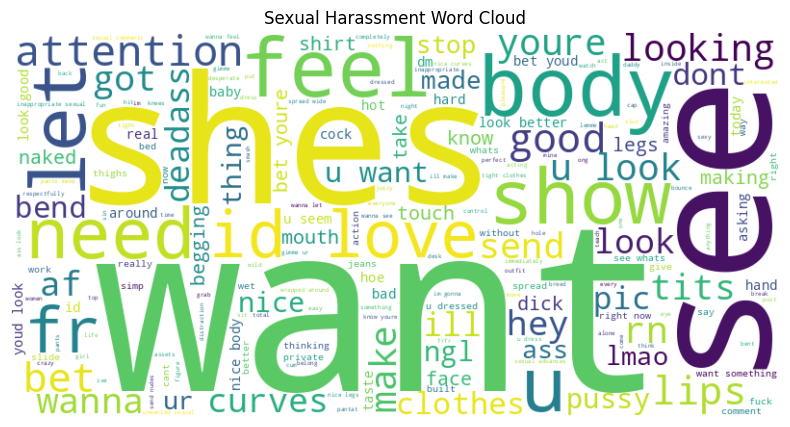

In [ ]:
text = ' '.join([w for tokens in df[df['Classification']=='Sexual Harassment']['Clean Split'] for w in tokens])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Sexual Harassment Word Cloud')
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(
    max_features = 5000,
    ngram_range = (1, 2)
)

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df['Classification'])

In [ ]:
X_text = vectorizer.fit_transform(df['Clean Words'])
X_emoji = df[["emoji_insult", "emoji_threat", "emoji_sexual_harassment"]].values

X = hstack([X_text, X_emoji])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print(f"Naive Bayes Accuracy : {accuracy_score(y_test, y_pred):.2f}")

Naive Bayes Accuracy : 0.90


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       434
           1       0.89      0.88      0.88       352
           2       0.90      0.89      0.90       397

    accuracy                           0.90      1183
   macro avg       0.90      0.90      0.90      1183
weighted avg       0.90      0.90      0.90      1183



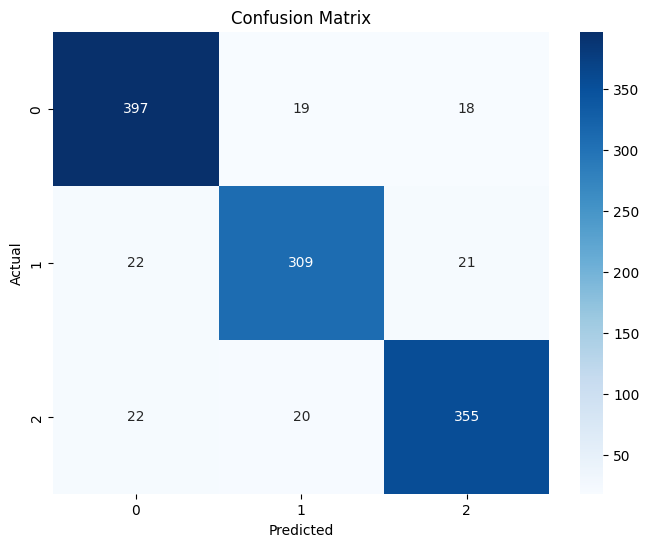

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()